In [1]:
# jax ecosystem
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_debug_nans", False)

device = jax.local_devices()[0]
print(device.device_kind)

stats = device.memory_stats()
free = stats["bytes_limit"] - stats["bytes_in_use"]
print(f"Total VRAM : {stats['bytes_limit'] / 1024**3:.2f} GB")
print(f"In use     : {stats['bytes_in_use'] / 1024**3:.2f} GB")
print(f"Free       : {free / 1024**3:.2f} GB")

import jax.numpy as np
import jax.tree as jtu
import jax.random as jr

# amigo
import amigo
import dorito
import zodiax

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# other
import pandas as pd
import os
import sys
# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]
viridis = mpl.colormaps["viridis"]
plasma = mpl.colormaps["plasma"]

inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
plasma.set_bad("k", 0.5)

if jax.config.read("jax_enable_x64"):
    print("64bit enabled")
else:
    print("32bit enabled")

import equinox
import lineax

print("jax version:", jax.__version__)
print("zodiax version:", zodiax.__version__)
print("amigo version:", amigo.__version__)
print("dorito version:", dorito.__version__)

print("equinox version:", equinox.__version__)
print("lineax version", lineax.__version__)

NVIDIA H200
Total VRAM : 104.79 GB
In use     : 0.00 GB
Free       : 104.79 GB
64bit enabled
jax version: 0.8.3
zodiax version: 0.4.1
amigo version: 0.0.10
dorito version: 0.2.0
equinox version: 0.13.7
lineax version 0.1.0


In [2]:
# Setting data path
from socket import gethostname

print(f"host name: {gethostname()}")

if (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    data_dir = "/Volumes/morgana2/snert/max/data/JWST/"
    cache_dir = "/Volumes/morgana2/snert/max/data/amigo_cache"
    amigo_files_path = "/Volumes/morgana2/snert/max/data/amigo_files/v_0.0.10"
    output_path = "/Users/mc/outputs/retrain"

elif gethostname().startswith("max-"):
    data_dir = "/home/dgxuser/max/data/JWST/"
    cache_dir = "/home/dgxuser/max/data/amigo_cache"
    amigo_files_path = "/home/dgxuser/max/data/amigo_files/v_0.0.10"
    output_path = "/home/dgxuser/max/outputs/retrain"

else:
    data_dir = "/fred/oz440/max/data/JWST/"
    cache_dir = "/fred/oz440/max/data/amigo_cache"
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.10"
    output_path = "/fred/oz440/max/outputs/retrain"


print(f"amigo_files_path: {amigo_files_path}")

host name: max-imagev2-0-22
amigo_files_path: /home/dgxuser/max/data/amigo_files/v_0.0.10


In [3]:
# Add extra bad pixels
badpix_bool = np.load(f"{cache_dir}/full_badpix.npy")
badpix_bool = badpix_bool.at[25, 74].set(True)
badpix = np.array(badpix_bool, dtype=int)

def add_badpix(file):
    file["BADPIX"].data = badpix
    file["BADPIX"].data[25, 74] = 1
    return file


# Visualising metadata in a table
def summarise_files(files):
    prog_ids = []
    fnames = []
    targets = []
    filts = []
    diths = []
    ngroups = []
    time = []
    pis = []
    cals = []

    for file in files:
        header = file[0].header

        prog_ids.append(header["PROGRAM"][1:])
        fnames.append(header["FILENAME"][:25])
        targets.append(header["TARGPROP"])
        filts.append(header["FILTER"])
        diths.append(f"{header["PATT_NUM"]}/{header["NUMDTHPT"]}")
        ngroups.append(f"{header["NGROUPS"]}/{header["NINTS"]}")
        time.append(header["DATE-BEG"])
        pis.append(header["PI_NAME"])
        try:
            cals.append(header["IS_PSF"])
        except KeyError:
            cals.append("FLAT")

    df = pd.DataFrame(
        {
            "program": prog_ids,
            # "filename": fnames,
            "target": targets,
            "filter": filts,
            "dither": diths,
            "g/i": ngroups,
            "date": time,
            "PI": pis,
            "CAL": cals,
        }
    )
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    df = df.assign(date=pd.to_datetime(df["date"]).dt.strftime("%d-%m-%Y"))

    with pd.option_context(
        "display.expand_frame_repr",
        False,
        "display.max_columns",
        None,
        "display.max_rows",
        None,
        "display.width",
        1000,
    ):
        print(df)

    # df.to_excel("cal_data.xlsx", index=False)

In [4]:
# LOADING IN DATA
from astropy.io import fits
from amigo.files import get_files
from dorito.misc import truncate_files


dark_files = []
print()
print("DARKS")
program_path = os.path.join(data_dir, "DARKS/calslope/")
files = get_files(program_path, "nis_calslope", EXP_TYPE="NIS_DARK")
dark_files += files

dark_files = [add_badpix(file) for file in dark_files]
# truncate_files(dark_files, 500)  # TRUNCATING RAMP
summarise_files(dark_files)

file_800, file_050 = dark_files


DARKS
  program   target filter dither      g/i date             PI   CAL
0    1499  UNKNOWN  F430M    1/1  800/270  NaN  Martel, Andre  FLAT
1    6652  UNKNOWN  F430M    1/1  50/3752  NaN  Martel, Andre  FLAT


In [11]:
def line_fit(pix_ramp, pix_cov):
    """
    Fit a line to a pixel ramp using generalised least squares.
    
    Accounts for correlated errors between ramp samples via the full
    covariance matrix, returning the slope (count rate) and intercept.

    Parameters
    ----------
    pix_ramp : (N,) array
        Ramp samples for a single pixel.
    pix_cov : (N, N) array
        Full covariance matrix of the ramp samples.

    Returns
    -------
    coeffs : (2,) array
        [slope, intercept] of the fitted line.
    errors : (2,) array
        [slope_err, intercept_err] — 1-sigma uncertainties on the fitted parameters.
    """

    # Sample indices as x-axis
    x = np.arange(len(pix_ramp), dtype=float)

    # Cholesky factorisation of the covariance matrix: C = L Lᵀ
    # L is used to whiten the data (decorrelate and normalise errors)
    L = np.linalg.cholesky(pix_cov)

    # Apply whitening transform to the design matrix [x, 1]
    # Equivalent to L⁻¹ @ X without explicitly inverting L
    A = np.linalg.solve(L, np.column_stack([x, np.ones_like(x)]))

    # Apply the same whitening transform to the data
    b = np.linalg.solve(L, pix_ramp)

    # Ordinary least squares on the whitened system
    # Equivalent to GLS: minimises (y - Xβ)ᵀ C⁻¹ (y - Xβ)
    coeffs, _, _, _ = np.linalg.lstsq(A, b, rcond=None)

    # Parameter covariance matrix — diagonal gives variance of slope and intercept
    param_cov = np.linalg.inv(A.T @ A)
    errors = np.sqrt(np.diag(param_cov))

    return coeffs, errors

fit_pixels_vmap = jax.jit(jax.vmap(jax.vmap(line_fit)))

def fit_pixels(ramp, cov, batch_size=60):
    """
    Fit all pixels, using batching if the ramp is too large for GPU memory.

    ramp : (N, 80, 80)
    cov  : (N, N, 80, 80)
    """
    ramp_t = np.moveaxis(ramp, 0, -1)              # (80, 80, N)
    cov_t  = np.moveaxis(cov, (0,1), (-2,-1))      # (80, 80, N, N)

    N = ramp.shape[0]

    if N <= 50:
        # Small enough to do all at once
        return fit_pixels_vmap(ramp_t, cov_t)
    else:
        # Batch over flattened pixel axis to avoid OOM
        ramp_flat = ramp_t.reshape(-1, N)           # (6400, N)
        cov_flat  = cov_t.reshape(-1, N, N)         # (6400, N, N)

        fit_batch = jax.jit(jax.vmap(line_fit))

        all_coeffs, all_errors = [], []
        for i in range(0, len(ramp_flat), batch_size):
            c, e = fit_batch(ramp_flat[i:i+batch_size], cov_flat[i:i+batch_size])
            all_coeffs.append(c)
            all_errors.append(e)

        coeffs = np.concatenate(all_coeffs).reshape(80, 80, 2)
        errors = np.concatenate(all_errors).reshape(80, 80, 2)
        return coeffs, errors

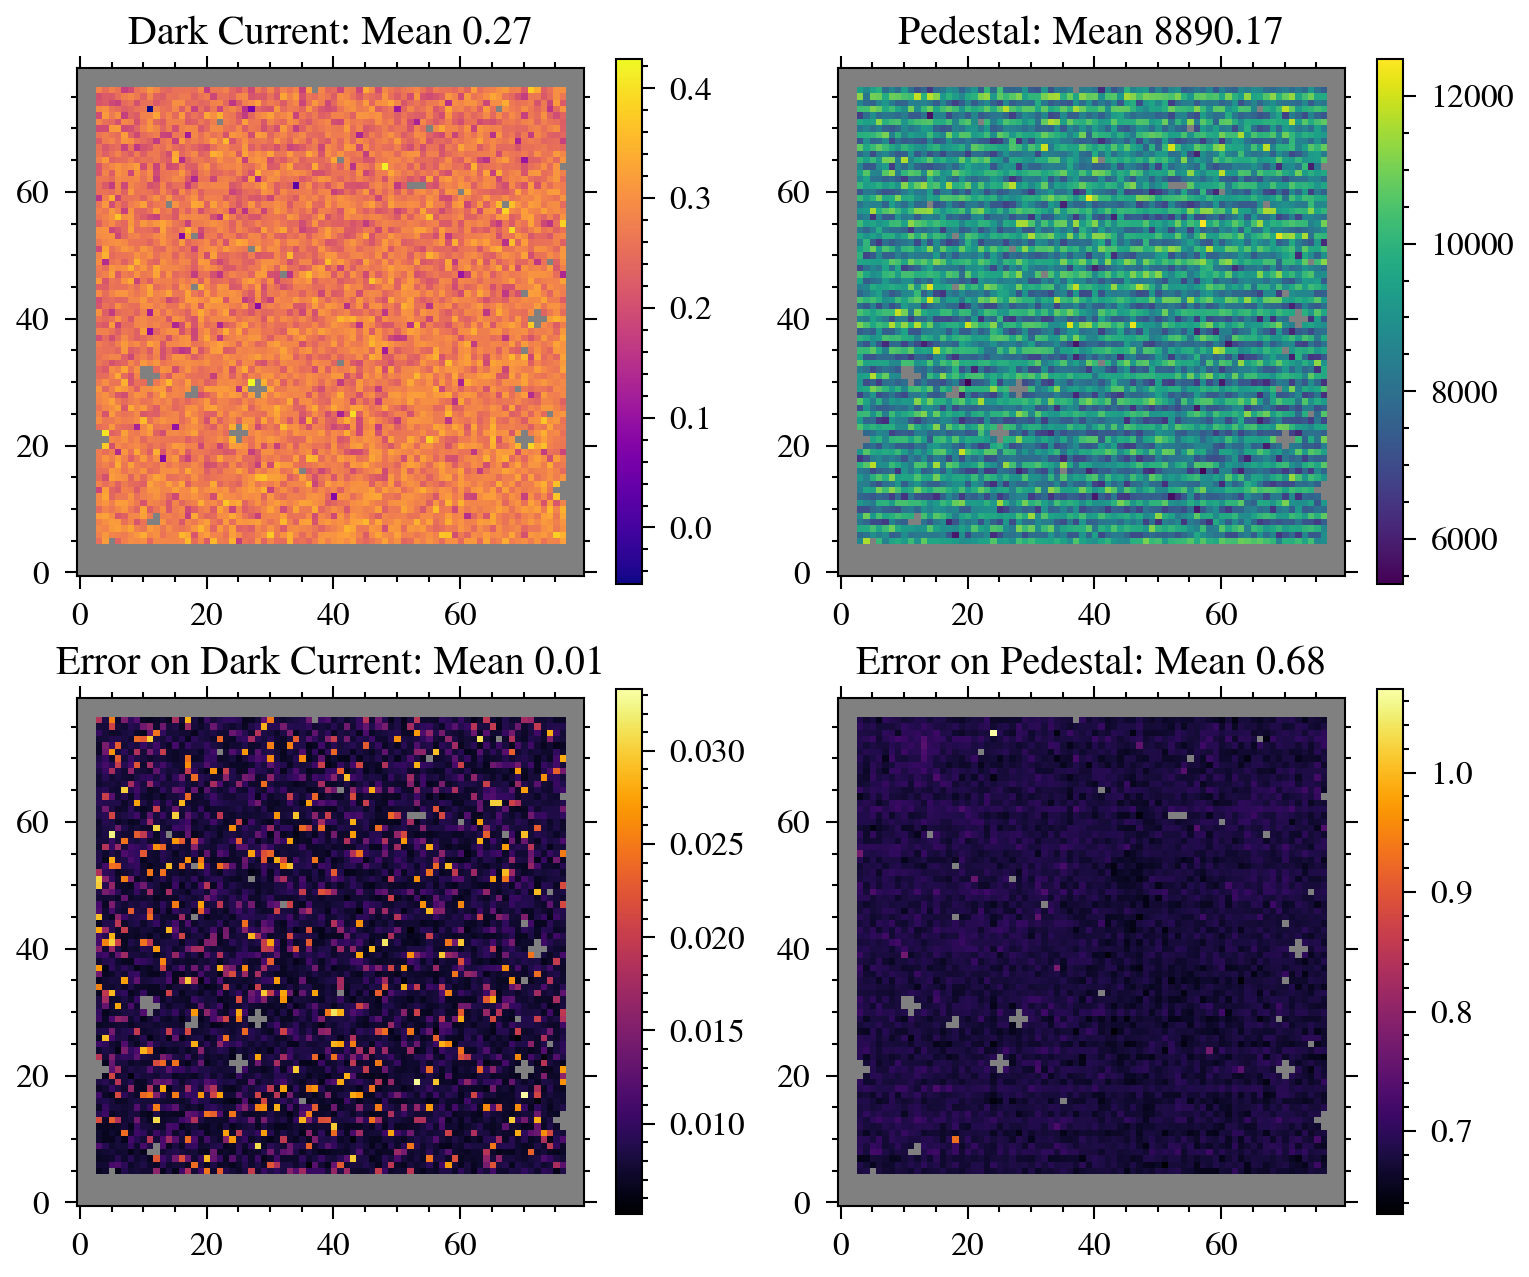

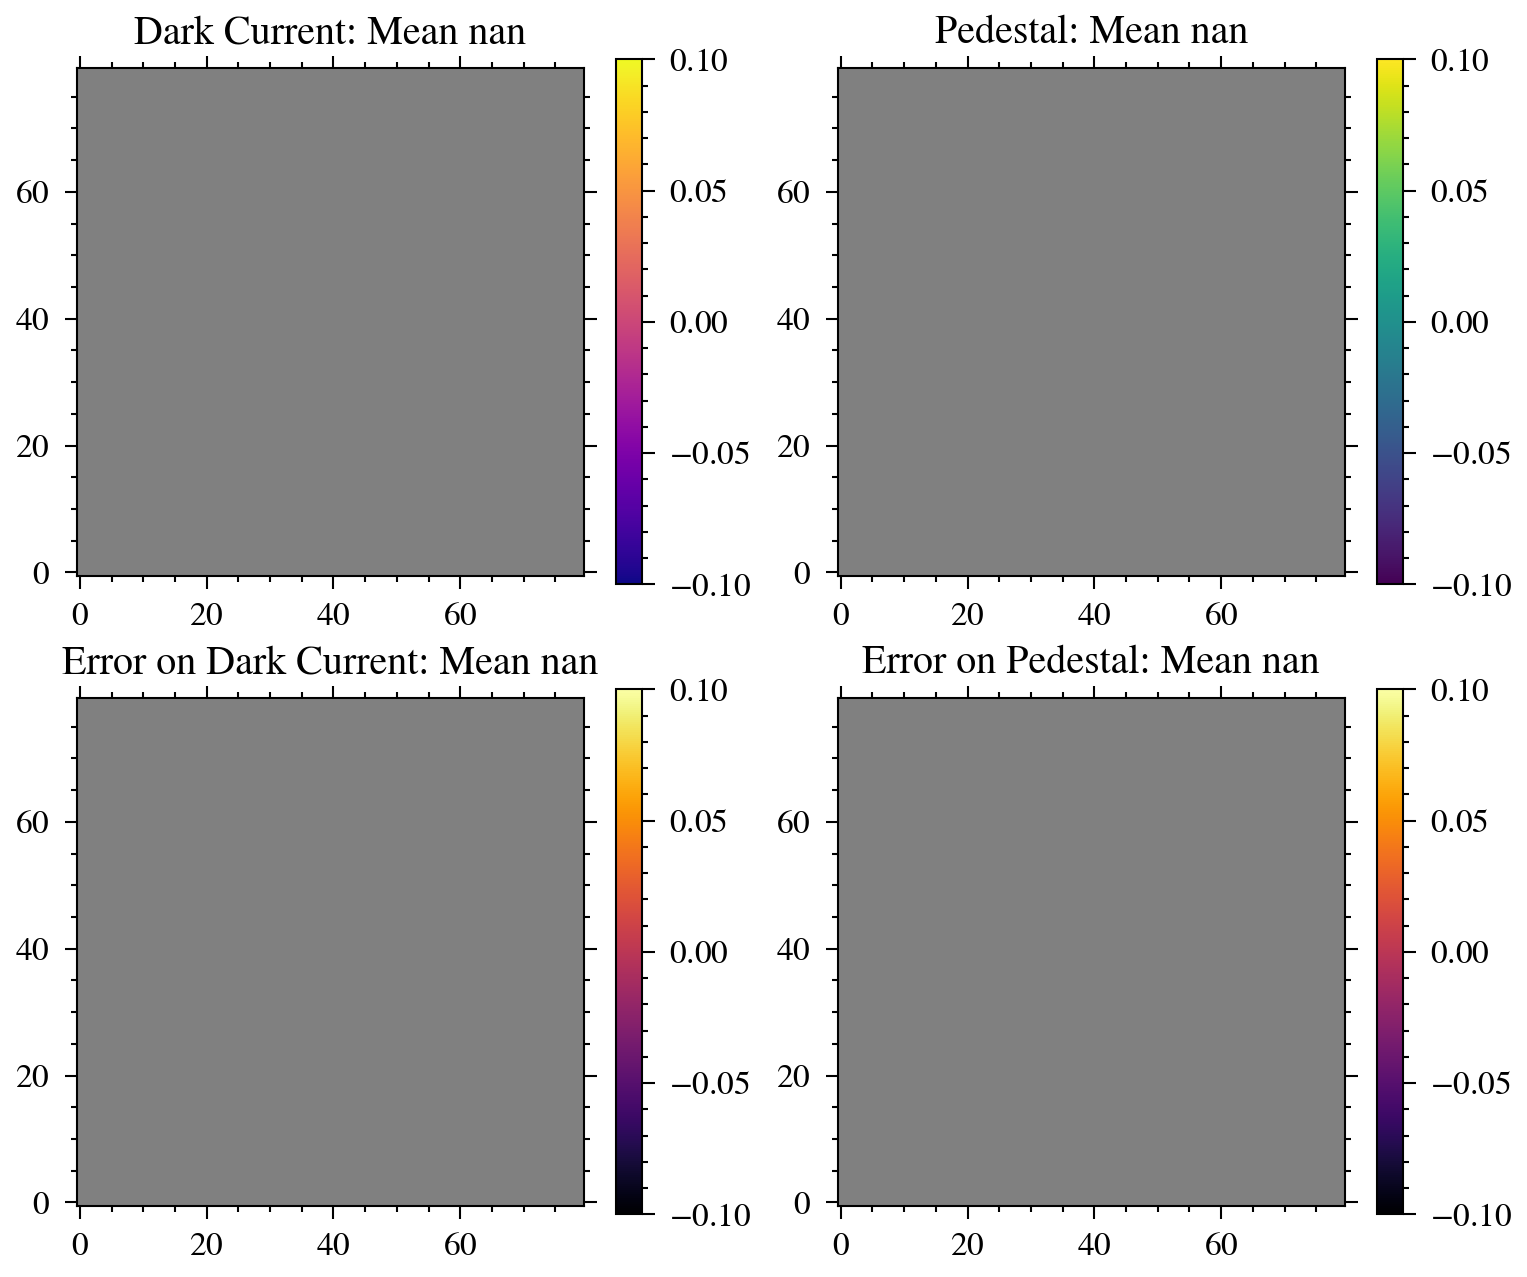

In [12]:
for file in [file_050, file_800]:

    ramp = np.array(file["RAMP"].data)
    cov  = np.array(file["RAMP_COV"].data)

    coeffs, errors = fit_pixels(ramp, cov)

    slope         = coeffs[..., 0]  # (80, 80)
    intercept     = coeffs[..., 1]  # (80, 80)
    slope_err     = errors[..., 0]  # (80, 80)
    intercept_err = errors[..., 1]  # (80, 80)

    fig, ax = plt.subplots(2, 2, figsize=(6, 5))

    # DARK CURRENT
    mean = np.nanmean(slope.at[badpix_bool].set(np.nan))
    im = ax[0][0].imshow(slope.at[badpix_bool].set(np.nan), plasma)
    ax[0][0].set(title=f"Dark Current: Mean {mean:.2f}")
    fig.colorbar(im, ax=ax[0][0])

    # PEDESTAL
    mean = np.nanmean(intercept.at[badpix_bool].set(np.nan))
    im = ax[0][1].imshow(intercept.at[badpix_bool].set(np.nan), viridis)
    ax[0][1].set(title=f"Pedestal: Mean {mean:.2f}")
    fig.colorbar(im, ax=ax[0][1])

    # ERROR ON DARK CURRENT
    mean = np.nanmean(slope_err.at[badpix_bool].set(np.nan))
    im = ax[1][0].imshow(slope_err.at[badpix_bool].set(np.nan), inferno)
    ax[1][0].set(title=f"Error on Dark Current: Mean {mean:.2f}")
    fig.colorbar(im, ax=ax[1][0])

    # ERROR ON PEDESTAL
    mean = np.nanmean(intercept_err.at[badpix_bool].set(np.nan))
    im = ax[1][1].imshow(intercept_err.at[badpix_bool].set(np.nan), inferno)
    ax[1][1].set(title=f"Error on Pedestal: Mean {mean:.2f}")
    fig.colorbar(im, ax=ax[1][1])

    plt.show()

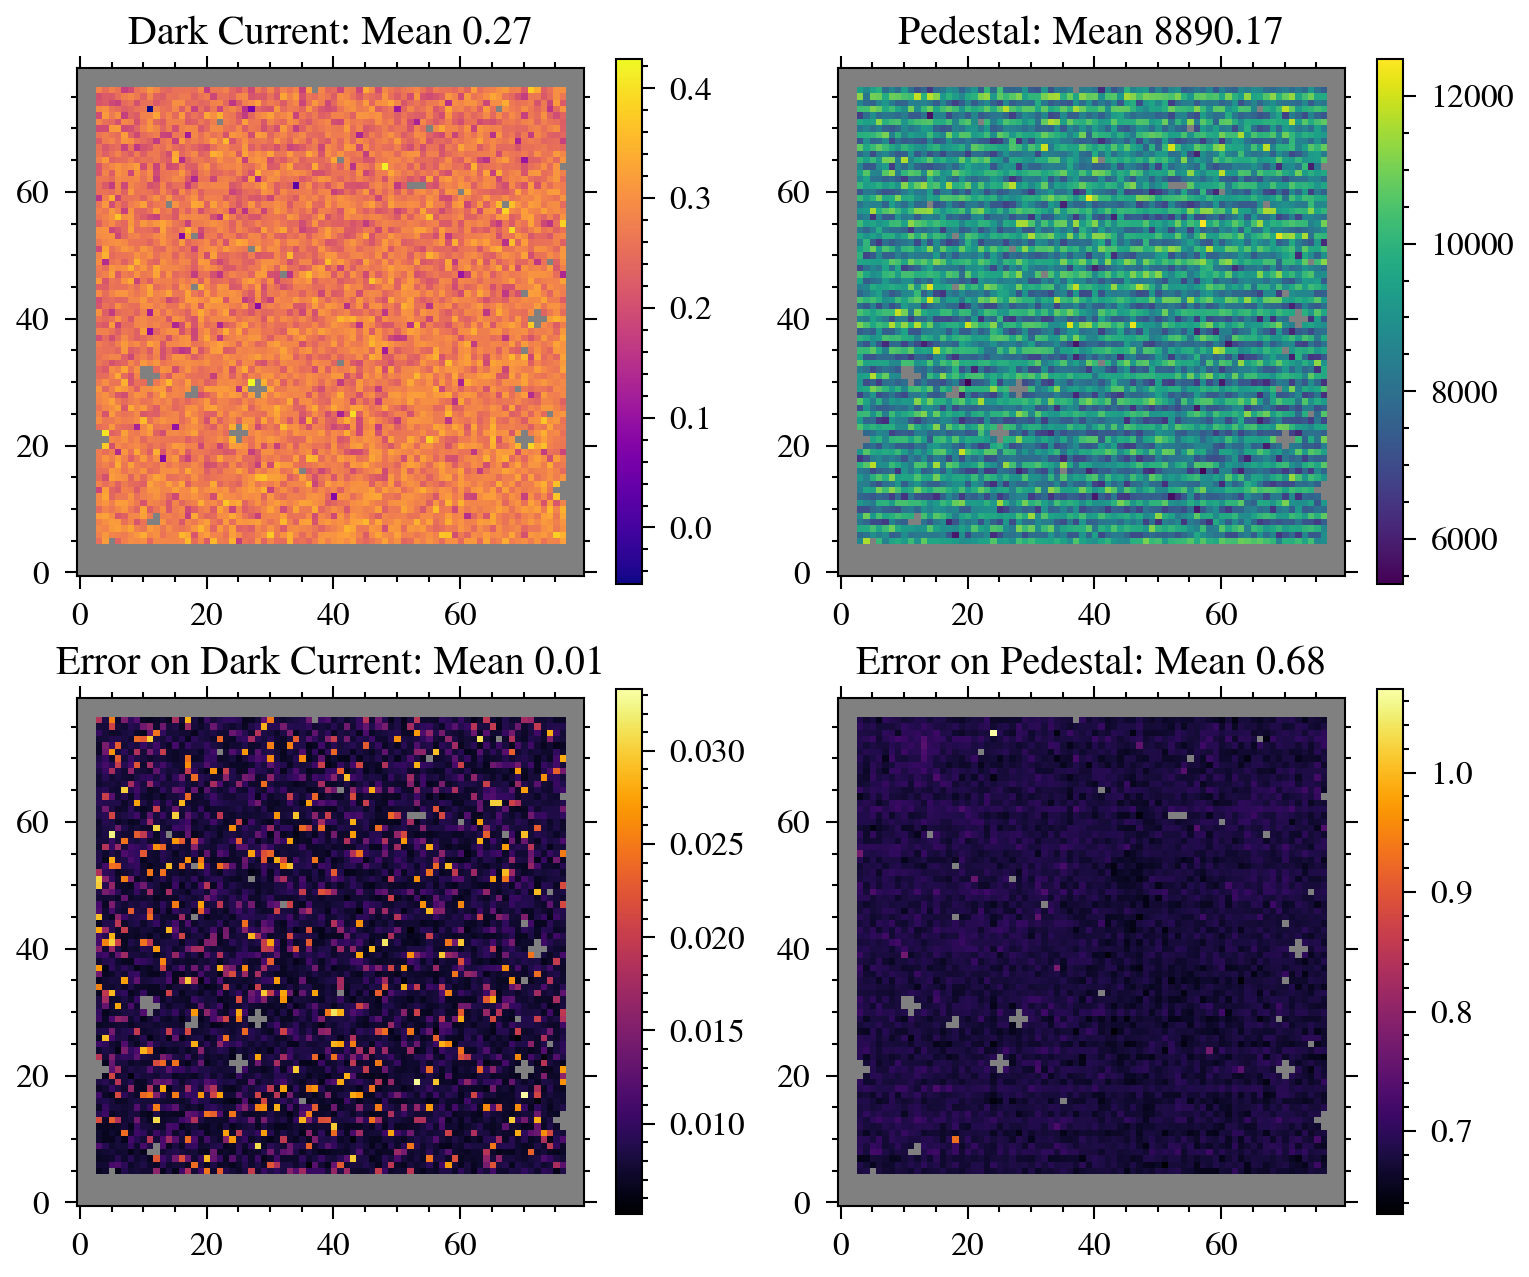

W0522 07:37:27.905786   23304 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 30.52GiB (rounded to 32768000000)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
W0522 07:37:27.905952   23304 bfc_allocator.cc:513] ****************************************************************************************____________
W0522 07:37:37.906160   23304 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 30.52GiB (rounded to 32768000000)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
W0522 07:37:37.906268   23304 bfc_allocator.cc:513] *************************************************************

JaxRuntimeError: INTERNAL: Autotuning failed for HLO: %input_transpose_fusion = f64[6400,800,800]{2,1,0} fusion(%a.1), kind=kInput, calls=%fused_transpose.2, metadata={op_name="jit(solve)/convert_element_type" stack_frame_id=2} with error: NOT_FOUND: No valid config found!

In [6]:
# for file in [file_050, file_800]:

#     ramp = np.array(file["RAMP"].data)
#     cov = np.array(file["RAMP_COV"].data)


#     # Move pixel axes to front for vmap: (80, 80, 50) and (80, 80, 50, 50)
#     ramp_t = np.moveaxis(ramp, 0, -1)        # (80, 80, 50)
#     cov_t  = np.moveaxis(cov, (0,1), (-2,-1)) # (80, 80, 50, 50)
    
#     # vmap over both pixel axes
#     fit_pixels = jax.vmap(jax.vmap(line_fit))
    
#     coeffs, errors = fit_pixels(ramp_t, cov_t)  # (80, 80, 2)
    
#     slope     = coeffs[..., 0]  # (80, 80)
#     intercept = coeffs[..., 1]  # (80, 80)
#     slope_err      = errors[..., 0]  # (80, 80)
#     intercept_err  = errors[..., 1]  # (80, 80)

#     fig, ax = plt.subplots(2, 2, figsize=(6, 5))

#     # DARK CURRENT
#     mean = np.nanmean(slope.at[badpix_bool].set(np.nan))
#     im = ax[0][0].imshow(slope.at[badpix_bool].set(np.nan), plasma)
#     ax[0][0].set(
#         title=f"Dark Current: Mean {mean:.2f}"
#     )
#     fig.colorbar(im, ax=ax[0][0])

#     # PEDESTAL
#     mean = np.nanmean(intercept.at[badpix_bool].set(np.nan))
#     im = ax[0][1].imshow(intercept.at[badpix_bool].set(np.nan), viridis)
#     ax[0][1].set(
#         title=f"Pedestal: Mean {mean:.2f}"
#     )
#     fig.colorbar(im, ax=ax[0][1])

#     # ERROR ON DARK CURRENT
#     mean = np.nanmean(slope_err.at[badpix_bool].set(np.nan))
#     im = ax[1][0].imshow(slope_err.at[badpix_bool].set(np.nan), inferno)
#     ax[1][0].set(
#         title=f"Error on Dark Current: Mean {mean:.2f}"
#     )
#     fig.colorbar(im, ax=ax[1][0])

#     # ERROR ON PEDESTAL
#     mean = np.nanmean(intercept_err.at[badpix_bool].set(np.nan))
#     im = ax[1][1].imshow(intercept_err.at[badpix_bool].set(np.nan), inferno)
#     ax[1][1].set(
#         title=f"Error on Pedestal: Mean {mean:.2f}"
#     )
#     fig.colorbar(im, ax=ax[1][1])
    
#     plt.show()

    

        


#     # for i in range(5):
#     #     for j in range(5):
            
#     #         pidx = (38+i, 38+j)
#     #         pix_ramp = ramp[:, pidx[0], pidx[1]]           # (50,)
#     #         pix_cov = cov[:, :, pidx[0], pidx[1]]     # (50, 50)
        
#     #         coeffs = line_fit(pix_ramp, pix_cov)
#     #         slope, intercept = coeffs
        
#     #         param_cov = np.linalg.inv(A.T @ A)
#     #         slope_err, intercept_err = np.sqrt(np.diag(param_cov))
        
#     #         # Plot with diagonal errors just for visualisation
#     #         perrors = np.sqrt(np.diag(pix_cov))
#     #         plt.errorbar(x, pix_ramp, yerr=perrors, fmt='o', ms=3)
#     #         plt.plot(x, slope * x + intercept, label=f'slope={slope:.3f} ± {slope_err:.3f}')
#     #         plt.xlim(0, len(pix_ramp))
#     #         plt.title(pidx)
#     #         plt.legend()
#     #         plt.show()